In [1]:
import torch

from chapter4.gpt_config import GPT_CONFIG_124M
from chapter5.train_model_simple import train_model_simple

torch.manual_seed(123)

In [2]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

In [3]:
file_path = "the_verdict.txt"
with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
validate_data = text_data[split_idx:]

In [4]:
from previous_chapters import create_dataloader_v1, GPTModel
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    validate_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [5]:
model = GPTModel(GPT_CONFIG_124M)
model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, "cuda" if torch.cuda.is_available() else "cpu", num_epochs=num_epochs, eval_freq=5, eval_iter=5, start_context="Every effort moves you", tokenizer=tokenizer
)

Epoch 1, step 0: train loss 9.7810, val loss 9.9328
Epoch 1, step 5: train loss 8.1105, val loss 8.3386
Every effort moves you,,,,,,,,,,,,.                                                                                                                                                                                                                                                   
Epoch 2, step 10: train loss 6.6609, val loss 7.0480
Epoch 2, step 15: train loss 5.9610, val loss 6.6160
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, a

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [9]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="train loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="val loss"
    )
    ax1.set_xlabel("epochs")
    ax1.set_ylabel("loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("tokens seen")
    fig.tight_layout()
    plt.show()

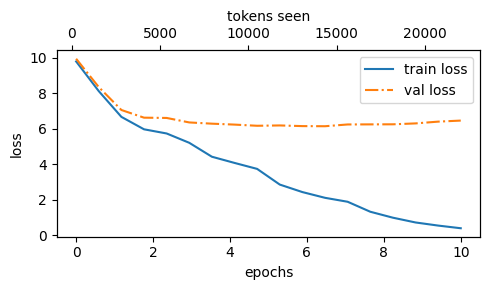

In [10]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)